<a href="https://colab.research.google.com/github/ripro805/Flower-Classification-cnn-project-/blob/main/flower_classification_with_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import kagglehub
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

#Download Dataset

In [34]:
path = kagglehub.dataset_download("marquis03/flower-classification")
print("Dataset Path:", path)

Using Colab cache for faster access to the 'flower-classification' dataset.
Dataset Path: /kaggle/input/flower-classification


#Check Dataset Structure

In [35]:
for root, dirs, files in os.walk(path):
    print(root)
    break

/kaggle/input/flower-classification


# Custom Dataset

In [36]:
class MultiClassDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform

        self.classes = sorted([
            d for d in os.listdir(root_dir)
            if os.path.isdir(os.path.join(root_dir, d))
        ])

        self.class_to_idx = {cls:i for i, cls in enumerate(self.classes)}

        valid_ext = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

        for cls in self.classes:
            cls_path = os.path.join(root_dir, cls)

            for file in os.listdir(cls_path):
                img_path = os.path.join(cls_path, file)

                if os.path.isfile(img_path) and file.lower().endswith(valid_ext):
                    label = self.class_to_idx[cls]
                    self.samples.append((img_path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

#Image Preprocessing

In [37]:
img_size = 128
batch_size = 32

transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

#Fixed dataset path

In [38]:
dataset_root = path

possible_train = os.path.join(path, "train")

if os.path.exists(possible_train):
    dataset_root = possible_train

print("Using dataset root:", dataset_root)

Using dataset root: /kaggle/input/flower-classification/train


#Load Dataset

In [39]:
dataset = MultiClassDataset(dataset_root, transform=transform)

print("Total samples:", len(dataset))
print("Classes:", dataset.classes)

if len(dataset) == 0:
    raise ValueError("Dataset empty! Check folder path or structure.")

Total samples: 13642
Classes: ['astilbe', 'bellflower', 'black_eyed_susan', 'calendula', 'california_poppy', 'carnation', 'common_daisy', 'coreopsis', 'dandelion', 'iris', 'rose', 'sunflower', 'tulip', 'water_lily']


# Train-Test Split

In [40]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

if train_size == 0 or test_size == 0:
    raise ValueError("Not enough data to split!")

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])


#Data Loader

In [41]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 342
Test batches: 86


# Show Flower Images

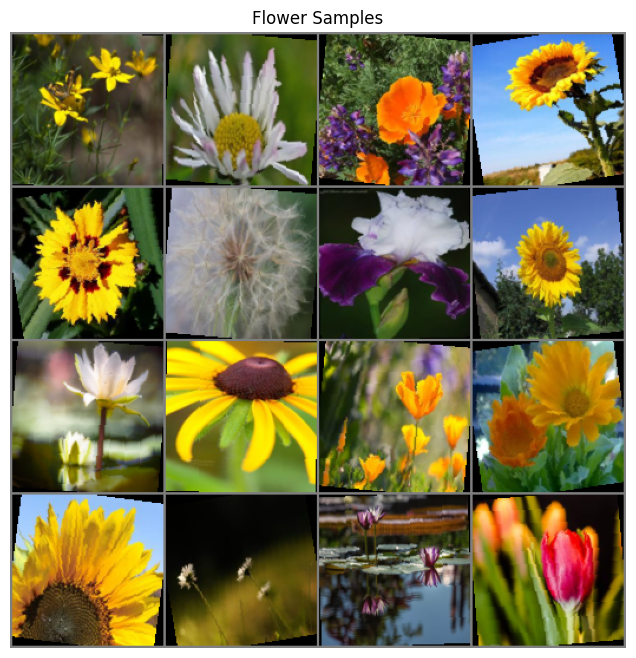

In [42]:
k = min(16, len(dataset))

indices = random.sample(range(len(dataset)), k)

images = []

for i in indices:
    img, _ = dataset[i]
    images.append(img)

grid = make_grid(images, nrow=4)

plt.figure(figsize=(8,8))
plt.imshow(grid.permute(1,2,0)*0.5 + 0.5)
plt.axis("off")
plt.title("Flower Samples")
plt.show()

# CNN Model

In [43]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128,256,3,padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*8*8,512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512,len(dataset.classes))
        )

    def forward(self,x):
        return self.classifier(self.features(x))

# Initialize Model

In [44]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN(len(dataset.classes)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Loop

In [ ]:
epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

# Accuracy Evaluation

In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Accuracy:", 100*correct/total)